# Actividad 3.1 - Modelo de IA supervisado

En el Parcial 2 hicimos un pipeline que limpia y valida 2000 notificaciones. En esta actividad usamos su salida para entrenar un modelo que anticipe si una notificación terminará rechazada.

La variable objetivo es **rechazado**: válido = 0 y rechazado = 1.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

Path("outputs").mkdir(exist_ok=True)
datos = pd.read_csv("dataset_modelo.csv")

print("Filas y columnas:", datos.shape)
datos.head()

Filas y columnas: (2000, 18)


,notification_id,event_id,event_type,user_id,source_user_id,post_id,comment_id,created_at,device,delivery_channel,priority,seen,status,app_version,country,latency_ms,motivo_rechazo,rechazado
0,N01807,E01807,COMMENT,U0056,U0200,P0041,C01807,2026-04-14 13:05:50,WEB,EMAIL,HIGH,True,SENT,0.9.0,AR,6215,SENT requiere app_version >= 1.0.0,1
1,N00388,E00388,COMMENT,U0049,U0106,P0036,C00388,2026-04-25 11:10:45,WEB,EMAIL,HIGH,False,SENT,1.2.0,CL,14035,NaN,0
2,N01673,E01673,FOLLOW,U0158,U0186,NaN,NaN,2026-04-19 13:28:10,WEB,EMAIL,MEDIUM,False,FAILED,1.2.0,AR,17184,NaN,0
3,N00592,E00592,COMMENT,U0182,U0169,P0031,C00592,2026-04-17 12:38:42,WEB,EMAIL,LOW,True,FAILED,2.0.0,PE,24171,NaN,0
4,N00302,E00302,LIKE,U0200,U0068,P0034,NaN,2026-04-26 19:26:18,MOBILE,PUSH,LOW,False,SENT,2.0.0,PE,7884,NaN,0


## 1. Calidad de los datos

Primero revisamos el tamaño, los duplicados, los nulos y algunas medidas estadísticas. Esto permite entender los datos antes de entrenar.

In [2]:
print("Total de filas:", len(datos))
print("Columnas:", datos.shape[1])
print("Duplicados completos:", datos.duplicated().sum())
ids_con_valor = datos["notification_id"].dropna()
print("Filas con Notification ID duplicado:", ids_con_valor.duplicated(keep=False).sum())
print("\nDistribución de la variable objetivo:")
print(datos["rechazado"].value_counts())
print("Tasa de rechazo:", round(datos["rechazado"].mean() * 100, 1), "%")

Total de filas: 2000
Columnas: 18
Duplicados completos: 0
Filas con Notification ID duplicado: 60

Distribución de la variable objetivo:
rechazado
0    1700
1     300
Name: count, dtype: int64
Tasa de rechazo: 15.0 %


In [3]:
resumen_nulos = pd.DataFrame({
    "nulos": datos.isna().sum(),
    "porcentaje": (datos.isna().mean() * 100).round(1)
})

resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("nulos", ascending=False)

,nulos,porcentaje
motivo_rechazo,1700,85.0
comment_id,1315,65.8
post_id,658,32.9
notification_id,20,1.0


Los nulos no significan siempre un error. `comment_id` puede faltar cuando no es un comentario y `post_id` puede faltar en un FOLLOW. En cambio, un `notification_id` vacío sí es un problema. `motivo_rechazo` queda vacío en las filas válidas porque no tienen motivo de rechazo.

In [4]:
latencia = pd.to_numeric(datos["latency_ms"], errors="coerce")

estadisticas_latencia = pd.DataFrame({
    "medida": ["media", "mediana", "moda", "mínimo", "percentil 25", "percentil 75", "máximo"],
    "latency_ms": [
        latencia.mean(), latencia.median(), latencia.mode().iloc[0], latencia.min(),
        latencia.quantile(0.25), latencia.quantile(0.75), latencia.max()
    ]
})
estadisticas_latencia["latency_ms"] = estadisticas_latencia["latency_ms"].round(1)
estadisticas_latencia

,medida,latency_ms
0,media,12518.4
1,mediana,12683.5
2,moda,288.0
3,mínimo,-4893.0
4,percentil 25,6155.8
5,percentil 75,18751.5
6,máximo,24991.0


In [5]:
columnas_categoricas = ["event_type", "device", "delivery_channel", "priority", "status", "country"]

modas = pd.DataFrame({
    "variable": columnas_categoricas,
    "moda": [datos[c].mode(dropna=True).iloc[0] for c in columnas_categoricas]
})
modas

,variable,moda
0,event_type,COMMENT
1,device,WEB
2,delivery_channel,IN_APP
3,priority,LOW
4,status,FAILED
5,country,AR


motivo_rechazo
duplicado_notification_id                                    30
timestamp_formato_invalido                                   25
latency_ms no puede ser negativo                             25
self-event: user_id igual a source_user_id                   25
status fuera de dominio                                      20
created_at no puede ser futuro                               20
delivery_channel fuera de dominio                            20
device fuera de dominio                                      20
priority fuera de dominio                                    20
notification_id vacio                                        20
event_type fuera de dominio                                  20
EMAIL fuera de horario permitido (07-23)                     15
country fuera de dominio                                     15
SENT requiere app_version >= 1.0.0                           10
FOLLOW no puede tener priority HIGH                          10
LIKE debe tener post_id  

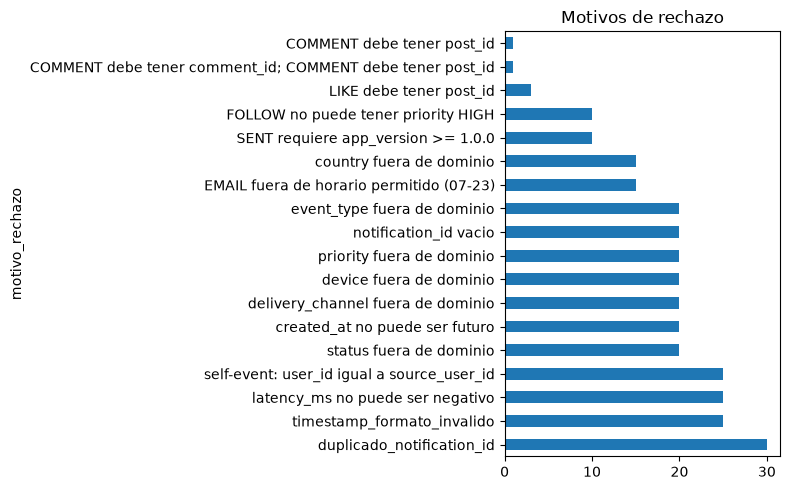

In [6]:
motivos = datos[datos["rechazado"] == 1]["motivo_rechazo"].value_counts()
print(motivos)

motivos.plot(kind="barh", figsize=(8, 5))
plt.title("Motivos de rechazo")
plt.tight_layout()
plt.savefig("outputs/eda_motivos.png")
plt.show()

## 2. Análisis univariado

Miramos cómo se distribuyen la prioridad y la latencia por separado.

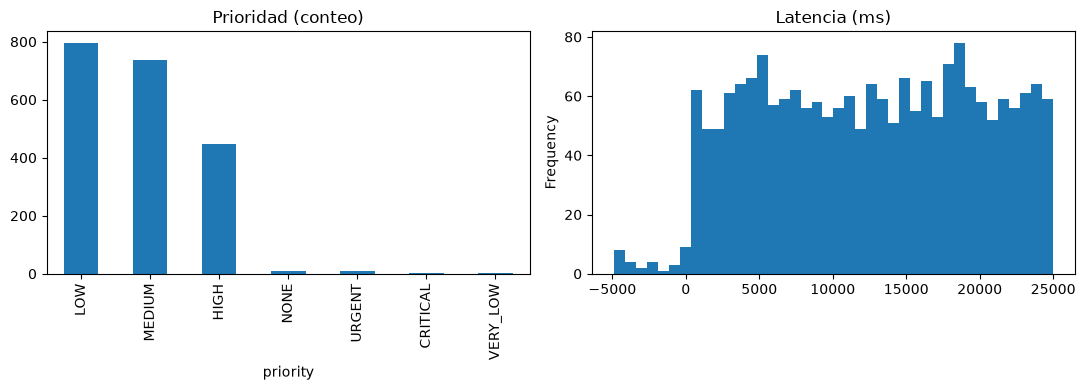

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
datos["priority"].value_counts().plot(kind="bar", ax=ejes[0], title="Prioridad (conteo)")
latencia.plot(kind="hist", bins=40, ax=ejes[1], title="Latencia (ms)")
plt.tight_layout()
plt.savefig("outputs/univariado.png")
plt.show()

## 3. Análisis bivariado

Cruzamos la prioridad con la variable objetivo para comparar la tasa de rechazo entre categorías.

priority
LOW         0.130653
MEDIUM      0.144986
HIGH        0.154709
CRITICAL    1.000000
NONE        1.000000
URGENT      1.000000
VERY_LOW    1.000000
Name: rechazado, dtype: float64


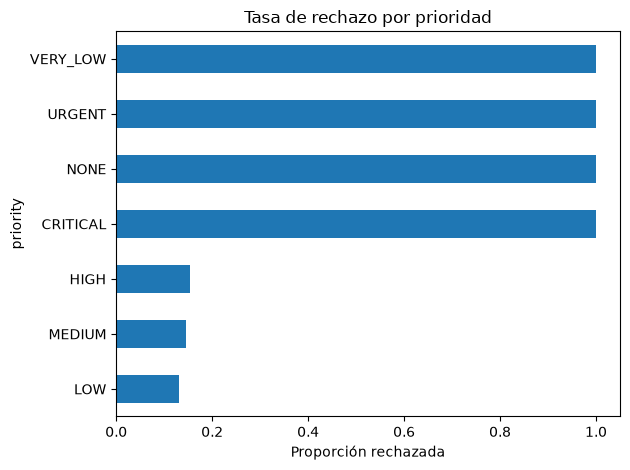

In [8]:
tasa = datos.groupby("priority")["rechazado"].mean().sort_values()
print(tasa)

tasa.plot(kind="barh", title="Tasa de rechazo por prioridad")
plt.xlabel("Proporción rechazada")
plt.tight_layout()
plt.savefig("outputs/bivariado.png")
plt.show()

## 4. Variable objetivo

Pensamos en predecir `status`, `seen` o `rechazado`. Como el dataset es sintético, `status` y `seen` tienen poca relación con las demás columnas. El rechazo sí depende de reglas de calidad, por eso elegimos predecir el **riesgo de rechazo**.

## 5. Preparar las variables

Creamos algunas banderas simples de calidad. No usamos `motivo_rechazo` ni los identificadores como entradas del modelo.

In [9]:
categoricas = ["event_type", "device", "delivery_channel", "priority", "status", "country", "app_version"]
numericas = ["latency_ms_num", "hora", "ts_invalido", "latency_negativa", "self_event",
             "n_campos_faltantes", "dup_notification_id", "falta_post_id", "falta_comment_id"]


def vacio(columna):
    texto = columna.astype("string").str.strip().str.upper()
    return columna.isna() | texto.isin(["", "NAN", "NONE"]).fillna(True)


def preparar_variables(df):
    d = df.copy()
    fecha = pd.to_datetime(d["created_at"], errors="coerce")
    lat = pd.to_numeric(d["latency_ms"], errors="coerce")

    d["hora"] = fecha.dt.hour
    d["ts_invalido"] = fecha.isna().astype(int)
    d["latency_negativa"] = (lat < 0).fillna(False).astype(int)
    d["latency_ms_num"] = lat

    user = d["user_id"].astype("string").str.strip()
    source = d["source_user_id"].astype("string").str.strip()
    d["self_event"] = (user.notna() & source.notna() & (user == source)).astype(int)
    d["n_campos_faltantes"] = sum(
        vacio(d[c]).astype(int)
        for c in ["notification_id", "event_id", "user_id", "source_user_id", "app_version"]
    )
    d["dup_notification_id"] = (
        d.duplicated("notification_id", keep=False) & ~vacio(d["notification_id"])
    ).astype(int)
    d["falta_post_id"] = vacio(d["post_id"]).astype(int)
    d["falta_comment_id"] = vacio(d["comment_id"]).astype(int)

    for c in categoricas:
        serie = d[c].astype("string").str.strip().str.upper()
        d[c] = serie.astype(object).where(serie.notna(), np.nan)

    return d[categoricas + numericas]


X = preparar_variables(datos)
y = datos["rechazado"]
print("Variables preparadas:", X.shape[1])

Variables preparadas: 16


## 6. Matriz de correlación

La correlación muestra qué variables numéricas se mueven junto con el rechazo. Un valor cercano a 1 o -1 indica una relación más fuerte; un valor cercano a 0 indica una relación débil.

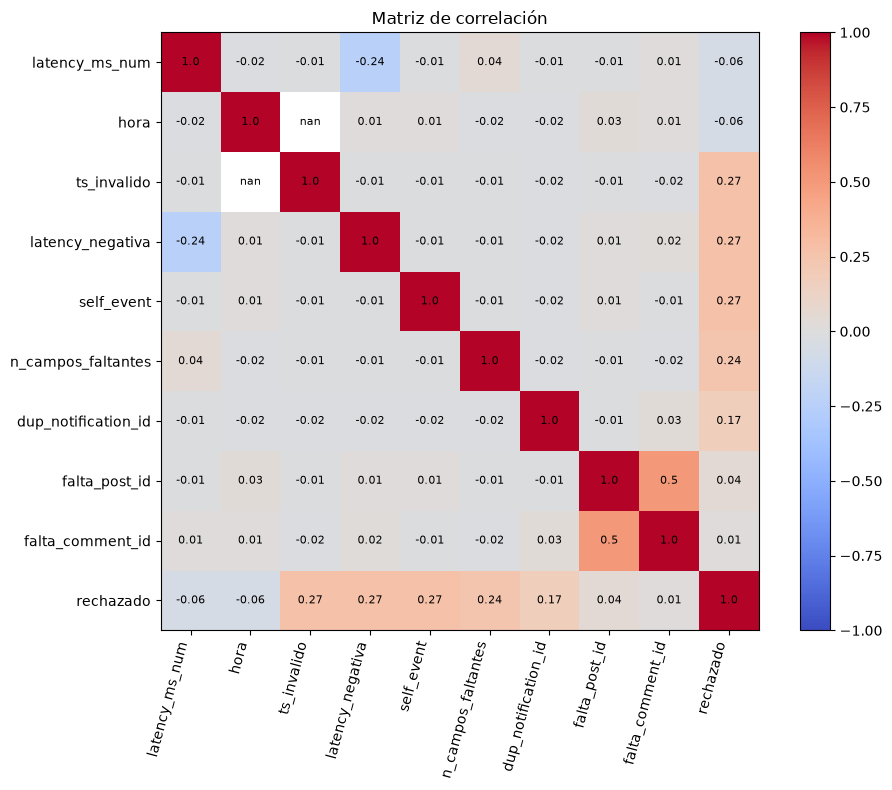

,rechazado
ts_invalido,0.27
self_event,0.27
latency_negativa,0.27
n_campos_faltantes,0.24
dup_notification_id,0.17
latency_ms_num,-0.06
hora,-0.06
falta_post_id,0.04
falta_comment_id,0.01


In [10]:
datos_correlacion = pd.concat([X[numericas], y], axis=1)
correlacion = datos_correlacion.corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
imagen = ax.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacion.columns)), correlacion.columns, rotation=75, ha="right")
ax.set_yticks(range(len(correlacion.index)), correlacion.index)

for i in range(len(correlacion.index)):
    for j in range(len(correlacion.columns)):
        ax.text(j, i, correlacion.iloc[i, j], ha="center", va="center", fontsize=8)

plt.colorbar(imagen, ax=ax)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.savefig("outputs/correlation_matrix.png")
plt.show()

correlacion_rechazo = correlacion["rechazado"].drop("rechazado")
correlacion_rechazo.reindex(correlacion_rechazo.abs().sort_values(ascending=False).index).to_frame()

La correlación sirve como apoyo, pero no prueba por sí sola que una variable cause el rechazo. Las banderas de calidad tienen sentido porque representan problemas que el pipeline ya revisa.

## 7. Separar entrenamiento y prueba

Usamos 80% para entrenar y 20% para probar, de forma estratificada. La imputación, la codificación y el escalado se aprenden solamente con entrenamiento.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)


def crear_preprocesamiento():
    proceso_numerico = Pipeline([
        ("completar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler())
    ])
    proceso_categorico = Pipeline([
        ("completar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer([
        ("numericas", proceso_numerico, numericas),
        ("categoricas", proceso_categorico, categoricas)
    ])


print("Entrenamiento:", len(X_train), "| Prueba:", len(X_test))

Entrenamiento: 1600 | Prueba: 400


## 8. Probar tres algoritmos

Comparamos los tres modelos con los mismos datos y elegimos el de mejor F1. Usamos `class_weight="balanced"` porque hay menos rechazados que válidos.

In [12]:
algoritmos = {
    "Regresión Logística": LogisticRegression(class_weight="balanced", max_iter=4000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(class_weight="balanced", max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42)
}

resultados = []
entrenados = {}

for nombre, algoritmo in algoritmos.items():
    modelo = Pipeline([
        ("preprocesamiento", crear_preprocesamiento()),
        ("modelo", algoritmo)
    ])
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_test)
    probabilidad = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probabilidad)

    entrenados[nombre] = modelo
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, prediccion),
        "precision": precision_score(y_test, prediccion),
        "recall": recall_score(y_test, prediccion),
        "f1": f1_score(y_test, prediccion),
        "AUC": auc,
        "Gini": 2 * auc - 1
    })

comparacion = pd.DataFrame(resultados).set_index("modelo").round(3)
mejor = comparacion["f1"].idxmax()
modelo_final = entrenados[mejor]

print(comparacion)
print("\nMejor modelo por F1:", mejor)

                     accuracy  precision  recall     f1    AUC   Gini
modelo                                                               
Regresión Logística     0.960      0.923   0.800  0.857  0.929  0.857
Árbol de Decisión       0.905      0.893   0.417  0.568  0.690  0.379
Random Forest           0.925      0.917   0.550  0.688  0.916  0.833

Mejor modelo por F1: Regresión Logística


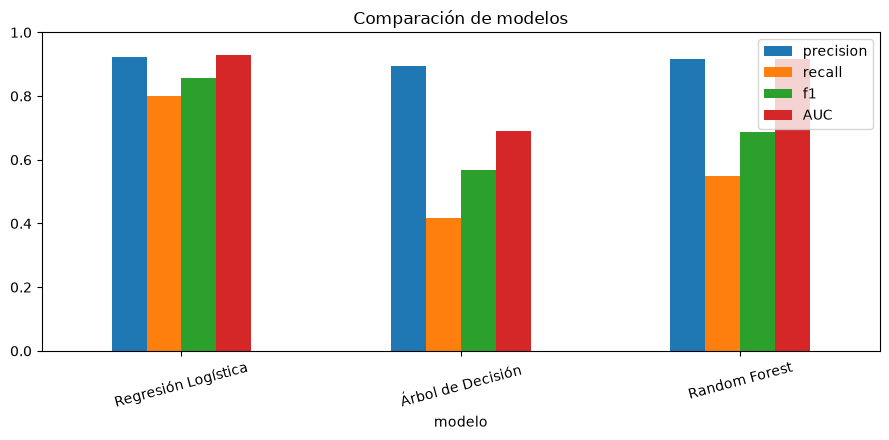

In [13]:
comparacion[["precision", "recall", "f1", "AUC"]].plot(kind="bar", figsize=(9, 4.5))
plt.title("Comparación de modelos")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("outputs/model_comparison.png")
plt.show()

Elegimos el modelo con mejor F1. También consideramos que la Regresión Logística es más fácil de explicar que un modelo de muchos árboles.

## 9. Resultados del modelo elegido

Evaluamos el modelo con las 400 notificaciones de prueba.

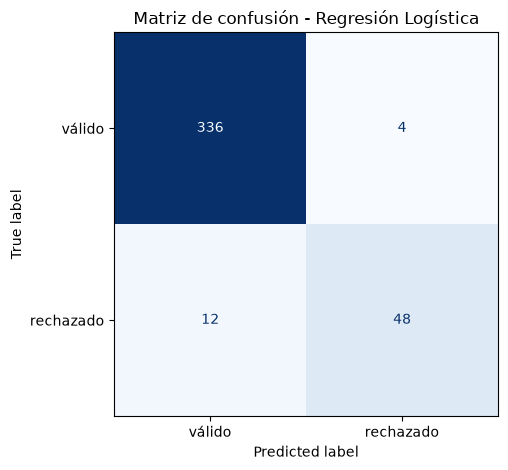

              precision    recall  f1-score   support

      válido       0.97      0.99      0.98       340
   rechazado       0.92      0.80      0.86        60

    accuracy                           0.96       400
   macro avg       0.94      0.89      0.92       400
weighted avg       0.96      0.96      0.96       400



In [14]:
pred = modelo_final.predict(X_test)
proba = modelo_final.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["válido", "rechazado"]).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - " + mejor)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png")
plt.show()

print(classification_report(y_test, pred, target_names=["válido", "rechazado"]))

Accuracy : 0.96
Precision: 0.923
Recall   : 0.8
F1       : 0.857
AUC      : 0.929
Gini     : 0.857


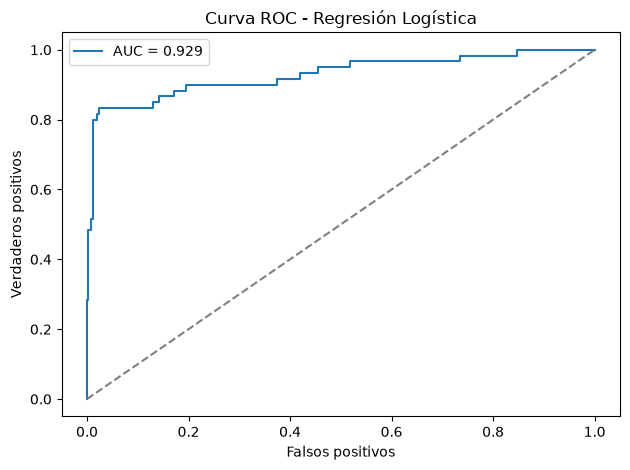

In [15]:
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, proba)
gini = 2 * auc - 1

print("Accuracy :", round(acc, 3))
print("Precision:", round(prec, 3))
print("Recall   :", round(rec, 3))
print("F1       :", round(f1, 3))
print("AUC      :", round(auc, 3))
print("Gini     :", round(gini, 3))

fpr, tpr, _ = roc_curve(y_test, proba)
plt.plot(fpr, tpr, label="AUC = " + str(round(auc, 3)))
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC - " + mejor)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png")
plt.show()

## 10. Guardar el modelo y los resultados

Guardamos el Pipeline completo. El archivo incluye imputación, codificación, escalado y modelo, así que no hay que repetir esos pasos manualmente al predecir.

In [16]:
metricas = {
    "actividad": "3.1 Modelo IA supervisado",
    "objetivo": "riesgo de rechazo (valido=0 / rechazado=1)",
    "modelo_final": mejor,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "calidad_datos": {
        "filas": int(datos.shape[0]),
        "columnas": int(datos.shape[1]),
        "tasa_rechazo": round(float(y.mean()), 4),
        "duplicados_completos": int(datos.duplicated().sum()),
        "nulos_notification_id": int(datos["notification_id"].isna().sum())
    },
    "metricas": {
        "accuracy": round(acc, 4), "precision": round(prec, 4),
        "recall": round(rec, 4), "f1": round(f1, 4),
        "auc": round(auc, 4), "gini": round(gini, 4)
    },
    "matriz_confusion": {
        "tn": int(cm[0, 0]), "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]), "tp": int(cm[1, 1])
    },
    "comparacion_modelos": comparacion.reset_index().round(3).to_dict(orient="records")
}

with open("outputs/metrics.json", "w", encoding="utf-8") as archivo:
    json.dump(metricas, archivo, indent=2, ensure_ascii=False)

correlacion.to_csv("outputs/correlation_matrix.csv")
joblib.dump(modelo_final, "outputs/modelo_riesgo_rechazo.joblib")

print("Guardamos las métricas, la correlación y el Pipeline entrenado.")

Guardamos las métricas, la correlación y el Pipeline entrenado.


In [17]:
modelo_cargado = joblib.load("outputs/modelo_riesgo_rechazo.joblib")
prediccion_guardada = modelo_cargado.predict(X_test.iloc[:5])

print("Predicciones de prueba:", prediccion_guardada.tolist())
print("El modelo guardado se pudo cargar y usar correctamente.")

Predicciones de prueba: [0, 0, 0, 0, 0]
El modelo guardado se pudo cargar y usar correctamente.


## 11. Conclusiones y limitaciones

El modelo aprende a anticipar reglas de calidad del pipeline. Su utilidad es funcionar como una alerta temprana, no reemplazar la validación original.

La principal limitación es que los datos son sintéticos y las métricas salen de una sola división 80/20. Además, antes de usar el modelo con un archivo nuevo hay que generar las mismas variables de calidad con `preparar_variables()`.